# Load RAG Eval Results
Loads `testingevals_a100` (results CSVs), `timingevals_a100/perfiii_*.csv`, and `timingevals_a100/trace_*.jsonl` into DataFrames with config columns parsed from filenames.

In [1]:
import os
import re
import json
import pandas as pd
from pathlib import Path

# Matches config.py: BASE_OUT + OUT_SUFFIX ("_local") on this machine.
# Update these two lines if you change config.py.
BASE = Path("/mnt/nvme1n1p1/zman/RAGMark/bench_raw_data")
TESTING_DIR  = BASE / "testingevals_local"
TIMING_DIR   = BASE / "timingevals_local"

# Figures/data (below) are written into the repo, not the data-output drive.
AE_EVAL_DIR = Path("/mnt/nvme1n1p1/zman/RAGMark/ae_evaluation")

In [2]:
pd.set_option('display.max_columns', None)


In [3]:
# Filename format (fields separated by ~):
# {model}~{dataset}~rag{use_rag}~k{topk}~comp{compress}~{compress_model}~r{compress_r}
# ~rerank{rerank}~n{rerank_k}~{rerank_model}~ret{index_model}~{text_data}~{index_data}
# ~batch{batch}~{batch_size}~pipe{pipeline}~dev{device_config}

CONFIG_KEYS = [
    "model", "dataset",
    "use_rag", "topk",
    "compress", "compress_model", "compress_r",
    "rerank", "rerank_k", "rerank_model",
    "index_model", "text_data", "index_data",
    "batch", "batch_size", "pipeline", "device_config",
]

def parse_config(stem: str) -> dict:
    """Parse RAG config from a filename stem (no prefix_, no extension)."""
    parts = stem.split("~")
    if len(parts) != len(CONFIG_KEYS):
        raise ValueError(f"Expected {len(CONFIG_KEYS)} fields, got {len(parts)}: {stem}")
    cfg = dict(zip(CONFIG_KEYS, parts))
    # Use removeprefix to strip exact leading tokens (not char-by-char like lstrip)
    cfg["use_rag"]       = int(cfg["use_rag"].removeprefix("rag"))
    cfg["topk"]          = int(cfg["topk"].removeprefix("k"))
    cfg["compress"]      = int(cfg["compress"].removeprefix("comp"))
    cfg["compress_r"]    = float(cfg["compress_r"].removeprefix("r"))
    cfg["rerank"]        = int(cfg["rerank"].removeprefix("rerank"))
    cfg["rerank_k"]      = int(cfg["rerank_k"].removeprefix("n"))
    cfg["index_model"]   = cfg["index_model"].removeprefix("ret")
    cfg["batch"]         = int(cfg["batch"].removeprefix("batch"))
    cfg["batch_size"]    = int(cfg["batch_size"])
    cfg["pipeline"]      = cfg["pipeline"].removeprefix("pipe")
    cfg["device_config"] = cfg["device_config"].removeprefix("dev")
    return cfg

def stem_from_path(path: Path, prefix: str) -> str:
    """Strip file prefix and extension to get the config stem."""
    name = path.stem  # e.g. results_Llama-3.2-1B~...
    return name[len(prefix) + 1:]  # +1 for the underscore

# Quick sanity check
sample = next(TESTING_DIR.glob("results_*.csv"))
print(parse_config(stem_from_path(sample, "results")))

{'model': 'Llama-3.2-1B-Instruct', 'dataset': 'squad_dataset', 'use_rag': 1, 'topk': 0, 'compress': 0, 'compress_model': 'none', 'compress_r': 1.0, 'rerank': 0, 'rerank_k': 0, 'rerank_model': 'none', 'index_model': 'e5-base-v2', 'text_data': 'test_sample_2018_sent', 'index_data': 'e5_Flat_index', 'batch': 0, 'batch_size': 1, 'pipeline': 'standard', 'device_config': '1da59e'}


## 1. Testing Results (`testingevals_a100/results_*.csv`)
Columns: `gold, prediction, rouge, f1, em, recall` + config columns

In [4]:
result_frames = []
for f in sorted(TESTING_DIR.glob("results_*.csv")):
    cfg = parse_config(stem_from_path(f, "results"))
    df = pd.read_csv(f)
    df.insert(0, "idx", range(len(df)))
    for k, v in cfg.items():
        df[k] = v
    result_frames.append(df)

df_results = pd.concat(result_frames, ignore_index=True)
print(f"df_results: {df_results.shape}")
df_results.head()

df_results: (7600, 24)


,idx,gold,prediction,rouge,f1,em,recall,model,dataset,use_rag,topk,compress,compress_model,compress_r,rerank,rerank_k,rerank_model,index_model,text_data,index_data,batch,batch_size,pipeline,device_config
0,0,"['Dennis Hull, as well as painter Manley MacDo...",The Beatles,0.0,0.0,0,0,Llama-3.2-1B-Instruct,hotpotqa_dataset,1,0,0,none,1.0,0,0,none,e5-base-v2,test_sample_2018_sent,e5_Flat_index,0,1,standard,1da59e
1,1,['Narcissa'],Tryphosa,0.0,0.0,0,0,Llama-3.2-1B-Instruct,hotpotqa_dataset,1,0,0,none,1.0,0,0,none,e5-base-v2,test_sample_2018_sent,e5_Flat_index,0,1,standard,1da59e
2,2,['yes'],"Karjiang is a mountain, and Sherpi Kangri is a...",0.0,0.0,0,0,Llama-3.2-1B-Instruct,hotpotqa_dataset,1,0,0,none,1.0,0,0,none,e5-base-v2,test_sample_2018_sent,e5_Flat_index,0,1,standard,1da59e
3,3,['about 7 million'],"1,000",0.0,0.0,0,0,Llama-3.2-1B-Instruct,hotpotqa_dataset,1,0,0,none,1.0,0,0,none,e5-base-v2,test_sample_2018_sent,e5_Flat_index,0,1,standard,1da59e
4,4,['neo-Nazi'],Rock,0.0,0.0,0,0,Llama-3.2-1B-Instruct,hotpotqa_dataset,1,0,0,none,1.0,0,0,none,e5-base-v2,test_sample_2018_sent,e5_Flat_index,0,1,standard,1da59e


## 2. Timing / Performance (`timingevals_a100/perfiii_*.csv`)
Each row = one query run; many timing/GPU columns + config columns.

In [5]:
import ast

def expand_dict_cols(df: pd.DataFrame) -> pd.DataFrame:
    """Expand dict-valued columns (string or real dicts) into flat columns, recursively."""
    while True:
        to_drop, new_cols = [], {}
        for col in df.columns:
            sample = df[col].dropna()
            if sample.empty:
                continue
            v = sample.iloc[0]
            # Handle both string-serialized dicts and actual dict objects
            if isinstance(v, str) and v.strip().startswith('{'):
                try:
                    parsed = df[col].map(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
                except Exception:
                    continue
            elif isinstance(v, dict):
                parsed = df[col]
            else:
                continue
            try:
                keys = list(parsed.dropna().iloc[0].keys())
                for k in keys:
                    suffix = f"gpu{k}" if isinstance(k, int) else k
                    new_cols[f"{col}_{suffix}"] = parsed.map(
                        lambda d, k=k: d.get(k) if isinstance(d, dict) else None
                    )
                to_drop.append(col)
            except Exception:
                pass
        if not to_drop:
            break
        df = df.drop(columns=to_drop)
        df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)
    return df


perf_frames = []
for f in sorted(TIMING_DIR.glob("perfiii_*.csv")):
    cfg = parse_config(stem_from_path(f, "perfiii"))
    df = pd.read_csv(f)
    df = expand_dict_cols(df)
    for k, v in cfg.items():
        df[k] = v
    perf_frames.append(df)

df_perf = pd.concat(perf_frames, ignore_index=True)
print(f"df_perf: {df_perf.shape}")
df_perf.head()

df_perf: (7600, 165)


,rag_total_timer,embed_timer,embed,faiss_timer,faiss,context_tokens_before,context_tokens_after,rag_total,ttft,decode_time,generate_total_time,generate,tokens_generated,tokens_per_second,rag_total_timer_iter_0,embed_timer_iter_0,embed_iter_0,faiss_timer_iter_0,faiss_iter_0,context_tokens_before_iter_0,context_tokens_after_iter_0,rag_total_iter_0,ttft_iter_0,decode_time_iter_0,generate_total_time_iter_0,generate_iter_0,tokens_generated_iter_0,tokens_per_second_iter_0,question,prediction,mode,idx,cuda_visible_devices,num_gpus,gpu_0_name,gpu_1_name,init_cpu_start,load_embedder_cpu_before,load_embedder_cpu_after,embedder_device,load_corpus_cpu_before,load_corpus_cpu_after,load_faiss_cpu_before,load_faiss_cpu_after,faiss_is_gpu,faiss_device,load_generator_cpu_before,load_generator_cpu_after,generator_device,rerank,rerank_model,rerank_top_n,embed_gpu_before_allocated,embed_gpu_before_peak,embed_gpu_after_allocated,embed_gpu_after_peak,faiss_nvml_before_gpu_0_used_mb,faiss_nvml_before_gpu_0_free_mb,faiss_nvml_before_gpu_1_used_mb,faiss_nvml_before_gpu_1_free_mb,faiss_nvml_after_gpu_0_used_mb,faiss_nvml_after_gpu_0_free_mb,faiss_nvml_after_gpu_1_used_mb,faiss_nvml_after_gpu_1_free_mb,gen_gpu_before_allocated,gen_gpu_before_peak,gen_gpu_all_before_gpu_0_allocated,gen_gpu_all_before_gpu_0_peak,gen_gpu_all_before_gpu_1_allocated,gen_gpu_all_before_gpu_1_peak,gen_gpu_all_after_gpu_0_allocated,gen_gpu_all_after_gpu_0_peak,gen_gpu_all_after_gpu_1_allocated,gen_gpu_all_after_gpu_1_peak,gen_gpu_after_allocated,gen_gpu_after_peak,embed_gpu_before_iter_0_allocated,embed_gpu_before_iter_0_peak,embed_gpu_after_iter_0_allocated,embed_gpu_after_iter_0_peak,faiss_nvml_before_gpu_0_iter_0_used_mb,faiss_nvml_before_gpu_0_iter_0_free_mb,faiss_nvml_before_gpu_1_iter_0_used_mb,faiss_nvml_before_gpu_1_iter_0_free_mb,faiss_nvml_after_gpu_0_iter_0_used_mb,faiss_nvml_after_gpu_0_iter_0_free_mb,faiss_nvml_after_gpu_1_iter_0_used_mb,faiss_nvml_after_gpu_1_iter_0_free_mb,gen_gpu_before_iter_0_allocated,gen_gpu_before_iter_0_peak,gen_gpu_all_before_gpu_0_iter_0_allocated,gen_gpu_all_before_gpu_0_iter_0_peak,gen_gpu_all_before_gpu_1_iter_0_allocated,gen_gpu_all_before_gpu_1_iter_0_peak,gen_gpu_all_after_gpu_0_iter_0_allocated,gen_gpu_all_after_gpu_0_iter_0_peak,gen_gpu_all_after_gpu_1_iter_0_allocated,gen_gpu_all_after_gpu_1_iter_0_peak,gen_gpu_after_iter_0_allocated,gen_gpu_after_iter_0_peak,energy_j_gpu0,energy_j_gpu1,power_mean_w_gpu0,power_mean_w_gpu1,init_gpu_start_gpu_0_allocated,init_gpu_start_gpu_0_peak,init_gpu_start_gpu_1_allocated,init_gpu_start_gpu_1_peak,load_embedder_gpu_after_allocated,load_embedder_gpu_after_peak,load_corpus_gpu_after_gpu_0_allocated,load_corpus_gpu_after_gpu_0_peak,load_corpus_gpu_after_gpu_1_allocated,load_corpus_gpu_after_gpu_1_peak,load_faiss_gpu_before_gpu_0_allocated,load_faiss_gpu_before_gpu_0_peak,load_faiss_gpu_before_gpu_1_allocated,load_faiss_gpu_before_gpu_1_peak,load_faiss_nvml_before_gpu_0_used_mb,load_faiss_nvml_before_gpu_0_free_mb,load_faiss_nvml_before_gpu_1_used_mb,load_faiss_nvml_before_gpu_1_free_mb,load_faiss_gpu_after_gpu_0_allocated,load_faiss_gpu_after_gpu_0_peak,load_faiss_gpu_after_gpu_1_allocated,load_faiss_gpu_after_gpu_1_peak,load_faiss_nvml_after_gpu_0_used_mb,load_faiss_nvml_after_gpu_0_free_mb,load_faiss_nvml_after_gpu_1_used_mb,load_faiss_nvml_after_gpu_1_free_mb,load_generator_gpu_after_allocated,load_generator_gpu_after_peak,util_mean_gpu0_sm_pct,util_mean_gpu0_mem_pct,util_mean_gpu1_sm_pct,util_mean_gpu1_mem_pct,util_peak_gpu0_sm_pct,util_peak_gpu0_mem_pct,util_peak_gpu1_sm_pct,util_peak_gpu1_mem_pct,model,dataset,use_rag,topk,compress,compress_model,compress_r,rerank_k,index_model,text_data,index_data,batch,batch_size,pipeline,device_config,rerank_timer,rerank_timer_iter_0,rerank_iter_0,load_reranker_gpu_before_allocated,load_reranker_gpu_before_peak,load_reranker_gpu_after_allocated,load_reranker_gpu_after_peak,compress_timer,compress_timer_iter_0,compress_iter_0
0,1.786071e+09,1.786071e+09,0

## 3. Traces (`timingevals_a100/trace_*.jsonl`)
Each line = one query.  
- `meta`: question, mode, idx  
- `trace_stage_durations`: per-stage timing (e.g. `generate`)  
- `samples`: time-series GPU/CPU power — aggregated here to mean/peak per GPU

In [6]:
trace_rows = []

for f in sorted(TIMING_DIR.glob("trace_*.jsonl")):
    cfg = parse_config(stem_from_path(f, "trace"))
    with open(f) as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            row = dict(cfg)

            # Meta fields
            meta = rec.get("meta", {})
            row["question"] = meta.get("question")
            row["mode"]     = meta.get("mode")
            row["idx"]      = meta.get("idx")

            # Markers (e.g. generate_start, generate_end timestamps)
            for marker, t in (rec.get("markers") or {}).items():
                row[f"marker_{marker}"] = t

            # Stage durations
            for stage, dur in (rec.get("trace_stage_durations") or {}).items():
                row[f"dur_{stage}"] = dur

            # Aggregate all sample sensor columns: mean and peak
            samples = rec.get("samples") or []
            if samples:
                sdf = pd.DataFrame(samples).drop(columns=["t"], errors="ignore")
                for col in sdf.columns:
                    row[f"{col}_mean"] = sdf[col].mean()
                    row[f"{col}_peak"] = sdf[col].max()

            trace_rows.append(row)

df_trace = pd.DataFrame(trace_rows)
print(f"df_trace: {df_trace.shape}")
df_trace.head()

df_trace: (2280, 53)


,model,dataset,use_rag,topk,compress,compress_model,compress_r,rerank,rerank_k,rerank_model,index_model,text_data,index_data,batch,batch_size,pipeline,device_config,question,mode,idx,marker_embed_start,marker_embed_end,marker_faiss_start,marker_faiss_end,marker_generate_start,marker_generate_end,dur_embed,dur_faiss,dur_generate,gpu0_power_w_mean,gpu0_power_w_peak,gpu0_sm_pct_mean,gpu0_sm_pct_peak,gpu0_mem_pct_mean,gpu0_mem_pct_peak,gpu0_mem_mb_mean,gpu0_mem_mb_peak,gpu1_power_w_mean,gpu1_power_w_peak,gpu1_sm_pct_mean,gpu1_sm_pct_peak,gpu1_mem_pct_mean,gpu1_mem_pct_peak,gpu1_mem_mb_mean,gpu1_mem_mb_peak,cpu_pct_mean,cpu_pct_peak,marker_rerank_start,marker_rerank_end,dur_rerank,marker_compress_start,marker_compress_end,dur_compress
0,Llama-3.2-1B-Instruct,hotpotqa_dataset,1,0,0,none,1.0,0,0,none,e5-base-v2,test_sample_2018_sent,e5_Flat_index,0,1,standard,1da59e,"Who else besides ""The Golden Jet"" was born in ...",single,0,0.000909,0.253428,0.254102,0.254111,0.255207,0.555510,0.252519,0.000009,0.300303,43.353926,124.902,3.462963,9,0.666667,3,11886.351852,11920.5,39.675481,39.776,0.0,0,0.0,0,9008.5,9008.5,170.357407,572.9,NaN,NaN,NaN,NaN,NaN,NaN
1,Llama-3.2-1B-Instruct,hotpotqa_dataset,1,0,0,none,1.0,0,0,none,e5-base-v2,test_sample_2018_sent,e5_Flat_index,0,1,standard,1da59e,"What is the first name of the woman who, like ...",single,1,0.000692,0.008577,0.011785,0.011790,0.015506,0.087720,0.007885,0.000005,0.072214,82.093300,114.377,9.000000,9,3.000000,3,11936.500000,11940.5,39.629300,39.761,0.0,0,0.0,0,9008.5,9008.5,133.030000,185.0,NaN,NaN,NaN,NaN,NaN,NaN
2,Llama-3.2-1B-Instruct,hotpotqa_dataset,1,0,0,none,1.0,0,0,none,e5-base-v2,test_sample_2018_sent,e5_Flat_index,0,1,standard,1da59e,Is Karjiang a mountain and Sherpi Kangri a mou...,single,2,0.000596,0.007958,0.008620,0.008625,0.010276,0.286756,0.007363,0.000005,0.276480,73.235069,107.854,36.724138,42,18.310345,23,11940.500000,11940.5,39.684828,39.767,0.0,0,0.0,0,9008.5,9008.5,156.631034,264.3,NaN,NaN,NaN,NaN,NaN,NaN
3,Llama-3.2-1B-Instruct,hotpotqa_dataset,1,0,0,none,1.0,0,0,none,e5-base-v2,test_sample_2018_sent,e5_Flat_index,0,1,standard,1da59e,How many visitors per year does the first stop...,single,3,0.000698,0.008443,0.009002,0.009008,0.010141,0.077926,0.007745,0.000006,0.067785,92.025875,135.813,41.500000,42,23.000000,23,11940.500000,11940.5,39.594750,39.670,0.0,0,0.0,0,9008.5,9008.5,134.537500,223.6,NaN,NaN,NaN,NaN,NaN,NaN
4,Llama-3.2-1B-Instruct,hotpotqa_dataset,1,0,0,none,1.0,0,0,none,e5-base-v2,test_sample_2018_sent,e5_Flat_index,0,1,standard,1da59e,What kind of ideology is Torment's drummer inv...,single,4,0.000521,0.012305,0.016078,0.016084,0.017713,0.053547,0.011783,0.000006,0.035834,87.601000,114.456,41.000000,41,23.000000,23,11940.500000,11940.5,39.606000,39.672,0.0,0,0.0,0,9008.5,9008.5,154.840000,296.2,NaN,NaN,NaN,NaN,NaN,NaN


## Summary

In [7]:
print("df_results columns:", list(df_results.columns))
print()
print("df_perf columns:",    list(df_perf.columns))
print()
print("df_trace columns:",   list(df_trace.columns))

df_results columns: ['idx', 'gold', 'prediction', 'rouge', 'f1', 'em', 'recall', 'model', 'dataset', 'use_rag', 'topk', 'compress', 'compress_model', 'compress_r', 'rerank', 'rerank_k', 'rerank_model', 'index_model', 'text_data', 'index_data', 'batch', 'batch_size', 'pipeline', 'device_config']

df_perf columns: ['rag_total_timer', 'embed_timer', 'embed', 'faiss_timer', 'faiss', 'context_tokens_before', 'context_tokens_after', 'rag_total', 'ttft', 'decode_time', 'generate_total_time', 'generate', 'tokens_generated', 'tokens_per_second', 'rag_total_timer_iter_0', 'embed_timer_iter_0', 'embed_iter_0', 'faiss_timer_iter_0', 'faiss_iter_0', 'context_tokens_before_iter_0', 'context_tokens_after_iter_0', 'rag_total_iter_0', 'ttft_iter_0', 'decode_time_iter_0', 'generate_total_time_iter_0', 'generate_iter_0', 'tokens_generated_iter_0', 'tokens_per_second_iter_0', 'question', 'prediction', 'mode', 'idx', 'cuda_visible_devices', 'num_gpus', 'gpu_0_name', 'gpu_1_name', 'init_cpu_start', 'load_em

In [8]:
for name, df in [("df_results", df_results), ("df_perf", df_perf), ("df_trace", df_trace)]:
    with open(BASE / f"{name}_columns.txt", "w") as f:
        f.write("\n".join(df.columns))
    print(f"Wrote {name}_columns.txt ({len(df.columns)} columns)")

Wrote df_results_columns.txt (24 columns)
Wrote df_perf_columns.txt (165 columns)
Wrote df_trace_columns.txt (53 columns)


In [9]:
df_perf.head()

,rag_total_timer,embed_timer,embed,faiss_timer,faiss,context_tokens_before,context_tokens_after,rag_total,ttft,decode_time,generate_total_time,generate,tokens_generated,tokens_per_second,rag_total_timer_iter_0,embed_timer_iter_0,embed_iter_0,faiss_timer_iter_0,faiss_iter_0,context_tokens_before_iter_0,context_tokens_after_iter_0,rag_total_iter_0,ttft_iter_0,decode_time_iter_0,generate_total_time_iter_0,generate_iter_0,tokens_generated_iter_0,tokens_per_second_iter_0,question,prediction,mode,idx,cuda_visible_devices,num_gpus,gpu_0_name,gpu_1_name,init_cpu_start,load_embedder_cpu_before,load_embedder_cpu_after,embedder_device,load_corpus_cpu_before,load_corpus_cpu_after,load_faiss_cpu_before,load_faiss_cpu_after,faiss_is_gpu,faiss_device,load_generator_cpu_before,load_generator_cpu_after,generator_device,rerank,rerank_model,rerank_top_n,embed_gpu_before_allocated,embed_gpu_before_peak,embed_gpu_after_allocated,embed_gpu_after_peak,faiss_nvml_before_gpu_0_used_mb,faiss_nvml_before_gpu_0_free_mb,faiss_nvml_before_gpu_1_used_mb,faiss_nvml_before_gpu_1_free_mb,faiss_nvml_after_gpu_0_used_mb,faiss_nvml_after_gpu_0_free_mb,faiss_nvml_after_gpu_1_used_mb,faiss_nvml_after_gpu_1_free_mb,gen_gpu_before_allocated,gen_gpu_before_peak,gen_gpu_all_before_gpu_0_allocated,gen_gpu_all_before_gpu_0_peak,gen_gpu_all_before_gpu_1_allocated,gen_gpu_all_before_gpu_1_peak,gen_gpu_all_after_gpu_0_allocated,gen_gpu_all_after_gpu_0_peak,gen_gpu_all_after_gpu_1_allocated,gen_gpu_all_after_gpu_1_peak,gen_gpu_after_allocated,gen_gpu_after_peak,embed_gpu_before_iter_0_allocated,embed_gpu_before_iter_0_peak,embed_gpu_after_iter_0_allocated,embed_gpu_after_iter_0_peak,faiss_nvml_before_gpu_0_iter_0_used_mb,faiss_nvml_before_gpu_0_iter_0_free_mb,faiss_nvml_before_gpu_1_iter_0_used_mb,faiss_nvml_before_gpu_1_iter_0_free_mb,faiss_nvml_after_gpu_0_iter_0_used_mb,faiss_nvml_after_gpu_0_iter_0_free_mb,faiss_nvml_after_gpu_1_iter_0_used_mb,faiss_nvml_after_gpu_1_iter_0_free_mb,gen_gpu_before_iter_0_allocated,gen_gpu_before_iter_0_peak,gen_gpu_all_before_gpu_0_iter_0_allocated,gen_gpu_all_before_gpu_0_iter_0_peak,gen_gpu_all_before_gpu_1_iter_0_allocated,gen_gpu_all_before_gpu_1_iter_0_peak,gen_gpu_all_after_gpu_0_iter_0_allocated,gen_gpu_all_after_gpu_0_iter_0_peak,gen_gpu_all_after_gpu_1_iter_0_allocated,gen_gpu_all_after_gpu_1_iter_0_peak,gen_gpu_after_iter_0_allocated,gen_gpu_after_iter_0_peak,energy_j_gpu0,energy_j_gpu1,power_mean_w_gpu0,power_mean_w_gpu1,init_gpu_start_gpu_0_allocated,init_gpu_start_gpu_0_peak,init_gpu_start_gpu_1_allocated,init_gpu_start_gpu_1_peak,load_embedder_gpu_after_allocated,load_embedder_gpu_after_peak,load_corpus_gpu_after_gpu_0_allocated,load_corpus_gpu_after_gpu_0_peak,load_corpus_gpu_after_gpu_1_allocated,load_corpus_gpu_after_gpu_1_peak,load_faiss_gpu_before_gpu_0_allocated,load_faiss_gpu_before_gpu_0_peak,load_faiss_gpu_before_gpu_1_allocated,load_faiss_gpu_before_gpu_1_peak,load_faiss_nvml_before_gpu_0_used_mb,load_faiss_nvml_before_gpu_0_free_mb,load_faiss_nvml_before_gpu_1_used_mb,load_faiss_nvml_before_gpu_1_free_mb,load_faiss_gpu_after_gpu_0_allocated,load_faiss_gpu_after_gpu_0_peak,load_faiss_gpu_after_gpu_1_allocated,load_faiss_gpu_after_gpu_1_peak,load_faiss_nvml_after_gpu_0_used_mb,load_faiss_nvml_after_gpu_0_free_mb,load_faiss_nvml_after_gpu_1_used_mb,load_faiss_nvml_after_gpu_1_free_mb,load_generator_gpu_after_allocated,load_generator_gpu_after_peak,util_mean_gpu0_sm_pct,util_mean_gpu0_mem_pct,util_mean_gpu1_sm_pct,util_mean_gpu1_mem_pct,util_peak_gpu0_sm_pct,util_peak_gpu0_mem_pct,util_peak_gpu1_sm_pct,util_peak_gpu1_mem_pct,model,dataset,use_rag,topk,compress,compress_model,compress_r,rerank_k,index_model,text_data,index_data,batch,batch_size,pipeline,device_config,rerank_timer,rerank_timer_iter_0,rerank_iter_0,load_reranker_gpu_before_allocated,load_reranker_gpu_before_peak,load_reranker_gpu_after_allocated,load_reranker_gpu_after_peak,compress_timer,compress_timer_iter_0,compress_iter_0
0,1.786071e+09,1.786071e+09,0

## Figure 4 reproduction — Reranking latency breakdown (Case 2)

Stacked per-stage latency (Embed / FAISS / Rerank / TTFT / Decode) by dataset, faceted by `topk`, grouped by generator model, with mean ROUGE-L annotated above each stack.

Requires a sweep run with `rerank=True` (e.g. `run_sweep_fig4_fig9.py`, which runs both `reranks=[False, True]`).

**Note on rerank latency:** `df_perf["rerank"]` is the on/off config flag (0/1) parsed from the filename, not a duration — `run_sweep.py` merges `init_timing.data` (which sets `"rerank": args.rerank`) into the per-query timing dict *after* the pipeline already recorded a `"rerank"` stage duration under the same key, so the duration gets silently overwritten before it's saved. The actual per-query rerank latency is still recoverable from `df_trace`'s `dur_rerank` column, computed independently from the `tracer.mark("rerank_start"/"rerank_end")` calls in `rag_system/pipelines/standard.py` — that path never collides with the config flag. Trace data is only sampled for the first 30 queries per config (see `do_trace = idx < 30` in `run_sweep.py`), so `dur_rerank` is a mean over that subset rather than the full eval set.

Saved figure to /mnt/nvme1n1p1/zman/RAGMark/ae_evaluation/figures/plots/fig4_case2_reranking.png
Saved underlying data (30 rows, one per model x dataset x topk) to /mnt/nvme1n1p1/zman/RAGMark/ae_evaluation/figures/data/fig4_case2_reranking_data.csv


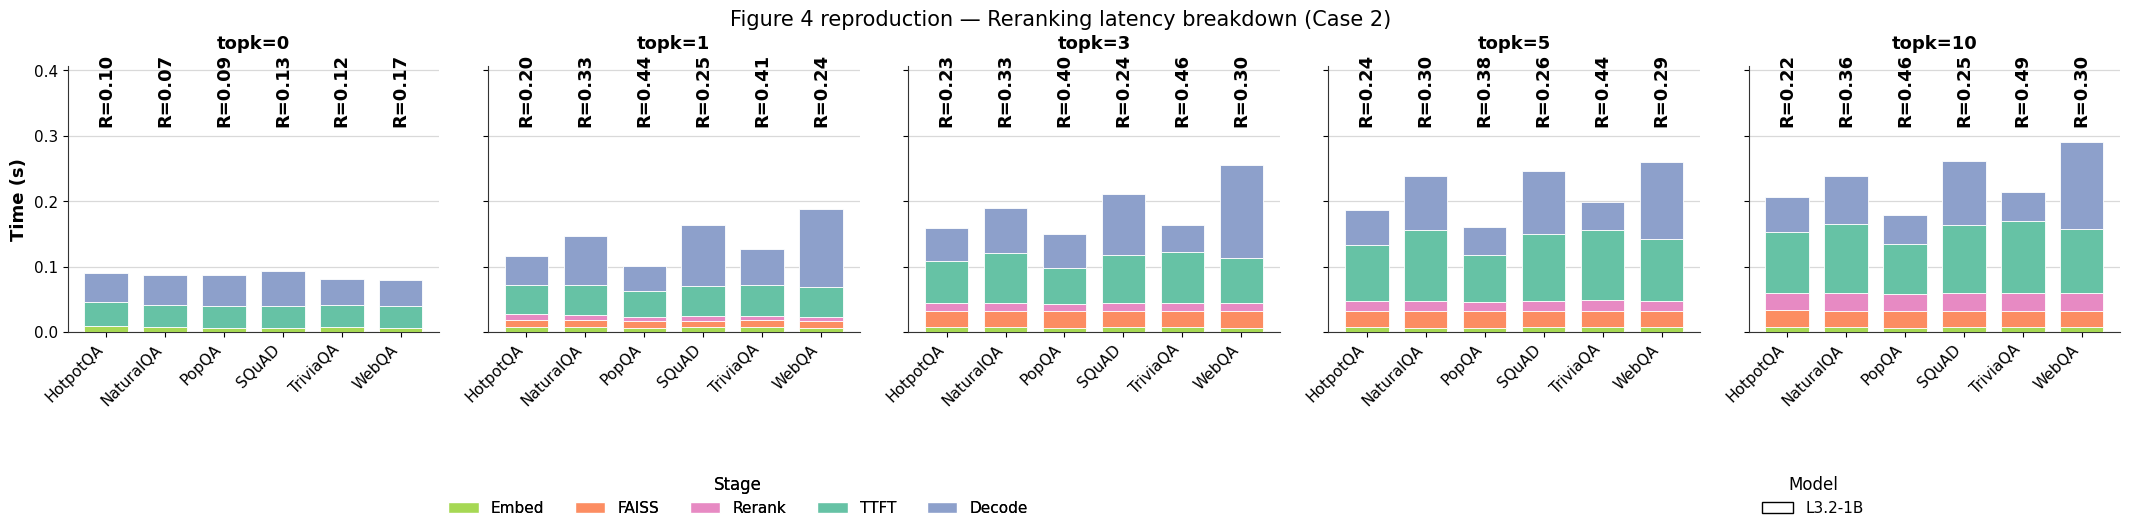

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Palette matched to the paper's own figures (Set2-style qualitative palette).
PALETTE = {
    "green": "#a6d854", "orange": "#fc8d62", "pink": "#e78ac3",
    "yellow": "#ffd92f", "teal": "#66c2a5", "blue": "#8da0cb",
}
INK, GRID_COLOR = "#000000", "#d9d9d9"

MODEL_ORDER  = ["Llama-3.2-1B-Instruct", "Llama-3.2-3B-Instruct", "Meta-Llama-3-8B-Instruct"]
MODEL_LABELS = {"Llama-3.2-1B-Instruct": "L3.2-1B", "Llama-3.2-3B-Instruct": "L3.2-3B",
                 "Meta-Llama-3-8B-Instruct": "L3-8B"}
MODEL_HATCH  = {"Llama-3.2-1B-Instruct": "", "Llama-3.2-3B-Instruct": "///",
                 "Meta-Llama-3-8B-Instruct": "xxx"}
MODEL_COLOR  = {"Llama-3.2-1B-Instruct": PALETTE["green"], "Llama-3.2-3B-Instruct": PALETTE["orange"],
                 "Meta-Llama-3-8B-Instruct": PALETTE["blue"]}

# Display names matching the paper's dataset labels (HotpotQA, NaturalQA, PopQA, SQuAD, TriviaQA, WebQA).
DATASET_LABELS = {
    "hotpotqa_dataset": "HotpotQA", "nq_dataset": "NaturalQA", "popqa_dataset": "PopQA",
    "squad_dataset": "SQuAD", "triviaqa_dataset": "TriviaQA", "webquestions_dataset": "WebQA",
}

STAGE_LABEL = {"embed": "Embed", "faiss": "FAISS", "dur_rerank": "Rerank",
               "dur_compress": "Compress", "ttft": "TTFT", "decode_time": "Decode"}
STAGE_COLOR = {"embed": PALETTE["green"], "faiss": PALETTE["orange"], "dur_rerank": PALETTE["pink"],
               "dur_compress": PALETTE["yellow"], "ttft": PALETTE["teal"], "decode_time": PALETTE["blue"]}

# Shared font sizes (bumped up across all three figures below).
FS_TICK, FS_LABEL, FS_TITLE, FS_LEGEND, FS_LEGEND_TITLE, FS_SUPTITLE = 11, 13, 13, 11, 12, 15

def style_axes(ax, grid_axis="y"):
    ax.set_facecolor("white")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#333333")
    ax.spines["bottom"].set_color("#333333")
    ax.tick_params(colors=INK, labelsize=FS_TICK)
    ax.grid(True, axis=grid_axis, color=GRID_COLOR, linewidth=0.9, zorder=0)
    ax.set_axisbelow(True)

STAGE_COLS = ["embed", "faiss", "dur_rerank", "ttft", "decode_time"]

c2_results = df_results[(df_results["rerank"] == 1) & (df_results["compress"] == 0)]
c2_perf    = df_perf[(df_perf["rerank"] == 1) & (df_perf["compress"] == 0)]
c2_trace   = df_trace[(df_trace["rerank"] == 1) & (df_trace["compress"] == 0)] if len(df_trace) else df_trace

GROUP = ["model", "dataset", "topk"]

if c2_results.empty or c2_perf.empty:
    print("No Case 2 (reranking) data found in df_results/df_perf — run a sweep with rerank=True first "
          "(e.g. run_sweep_fig4_fig9.py).")
else:
    rouge_tbl = c2_results.groupby(GROUP)["rouge"].mean().reset_index()
    perf_tbl  = c2_perf.groupby(GROUP)[["embed", "faiss", "ttft", "decode_time"]].mean().reset_index()

    if len(c2_trace) and "dur_rerank" in c2_trace.columns:
        rerank_tbl = c2_trace.groupby(GROUP)["dur_rerank"].mean().reset_index()
    else:
        rerank_tbl = pd.DataFrame(columns=GROUP + ["dur_rerank"])

    fig4_tbl = perf_tbl.merge(rerank_tbl, on=GROUP, how="left").merge(rouge_tbl, on=GROUP, how="left")
    fig4_tbl["dur_rerank"] = fig4_tbl["dur_rerank"].fillna(0.0)

    datasets = sorted(fig4_tbl["dataset"].unique())
    topks    = sorted(fig4_tbl["topk"].unique())
    models   = [m for m in MODEL_ORDER if m in fig4_tbl["model"].unique()]
    bar_w    = 0.8 / max(len(models), 1)

    # Precompute the global tallest bar so every R= annotation can sit at one fixed height,
    # shared across all datasets and all topk facets (instead of hugging each bar's own top).
    global_max_bottom = fig4_tbl[STAGE_COLS].sum(axis=1).max()
    annot_y = global_max_bottom * 1.08

    fig, axes = plt.subplots(1, len(topks), figsize=(4.3 * len(topks), 5.2), sharey=True)
    axes = np.atleast_1d(axes)

    for ax, topk in zip(axes, topks):
        sub = fig4_tbl[fig4_tbl["topk"] == topk]
        for mi, model in enumerate(models):
            msub = sub[sub["model"] == model].set_index("dataset").reindex(datasets)
            x = np.arange(len(datasets)) + (mi - (len(models) - 1) / 2) * bar_w
            bottom = np.zeros(len(datasets))
            for stage in STAGE_COLS:
                vals = msub[stage].fillna(0.0).values
                ax.bar(x, vals, width=bar_w * 0.92, bottom=bottom,
                       color=STAGE_COLOR[stage], hatch=MODEL_HATCH[model],
                       edgecolor="white", linewidth=0.6, zorder=3)
                bottom += vals

        # One ROUGE annotation per dataset cluster (mean across models), aligned at the same
        # fixed height across every subplot, matching the paper's density.
        rouge_per_dataset = sub.groupby("dataset")["rouge"].mean().reindex(datasets)
        xc = np.arange(len(datasets))
        for xi, r in zip(xc, rouge_per_dataset.values):
            if not np.isnan(r):
                ax.text(xi, annot_y, f"R={r:.2f}",
                        ha="center", va="bottom", fontsize=13, color=INK, fontweight="bold", rotation=90)

        ax.set_title(f"topk={topk}", fontsize=FS_TITLE, color=INK, fontweight="bold", pad=12)
        ax.set_xticks(np.arange(len(datasets)))
        ax.set_xticklabels([DATASET_LABELS.get(d, d.replace("_dataset", "")) for d in datasets],
                            rotation=45, ha="right", fontsize=FS_TICK)
        style_axes(ax)

    axes[0].set_ylim(0, max(global_max_bottom * 1.4, 1e-6))
    axes[0].set_ylabel("Time (s)", fontsize=FS_LABEL, color=INK, fontweight="bold")

    plt.tight_layout()
    fig.subplots_adjust(bottom=0.40)

    stage_handles = [plt.Rectangle((0, 0), 1, 1, facecolor=STAGE_COLOR[s], edgecolor="white") for s in STAGE_COLS]
    leg1 = fig.legend(stage_handles, [STAGE_LABEL[s] for s in STAGE_COLS], title="Stage",
                       loc="lower center", ncol=len(STAGE_COLS), bbox_to_anchor=(0.35, 0.02),
                       frameon=False, fontsize=FS_LEGEND, title_fontsize=FS_LEGEND_TITLE)
    fig.add_artist(leg1)
    model_handles = [plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor=INK, hatch=MODEL_HATCH[m])
                      for m in models]
    fig.legend(model_handles, [MODEL_LABELS.get(m, m) for m in models], title="Model",
               loc="lower center", ncol=len(models), bbox_to_anchor=(0.85, 0.02),
               frameon=False, fontsize=FS_LEGEND, title_fontsize=FS_LEGEND_TITLE)

    fig.suptitle("Figure 4 reproduction — Reranking latency breakdown (Case 2)",
                 y=1.02, fontsize=FS_SUPTITLE, color=INK)

    PLOTS_DIR = AE_EVAL_DIR / "figures" / "plots"
    DATA_DIR  = AE_EVAL_DIR / "figures" / "data"
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    fig_path = PLOTS_DIR / "fig4_case2_reranking.png"
    data_path = DATA_DIR / "fig4_case2_reranking_data.csv"
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    fig4_tbl.to_csv(data_path, index=False)
    print(f"Saved figure to {fig_path}")
    print(f"Saved underlying data ({len(fig4_tbl)} rows, one per model x dataset x topk) to {data_path}")

    plt.show()

## Figure 9 reproduction — System metrics vs ROUGE-L (Case 1, naive)

Scatter of ROUGE-L against TTFT, decode time, peak GPU0 memory, and mean GPU0 SM utilization, one point per `(model, topk)`, for the naive pipeline (`rerank=False, compress=False`).

Memory uses `gen_gpu_all_after_gpu_0_peak` (PyTorch peak-allocated memory on GPU0 right after generation) and SM% uses `util_mean_gpu0_sm_pct` (mean NVML SM utilization sampled by `PowerPoller` over the query) — the closest per-query fields to the paper's Table 5 GB / SM% columns available in `df_perf`.

Saved figure to /mnt/nvme1n1p1/zman/RAGMark/ae_evaluation/figures/plots/fig9_case1_naive.png
Saved underlying data (5 rows, one per model x topk) to /mnt/nvme1n1p1/zman/RAGMark/ae_evaluation/figures/data/fig9_case1_naive_data.csv


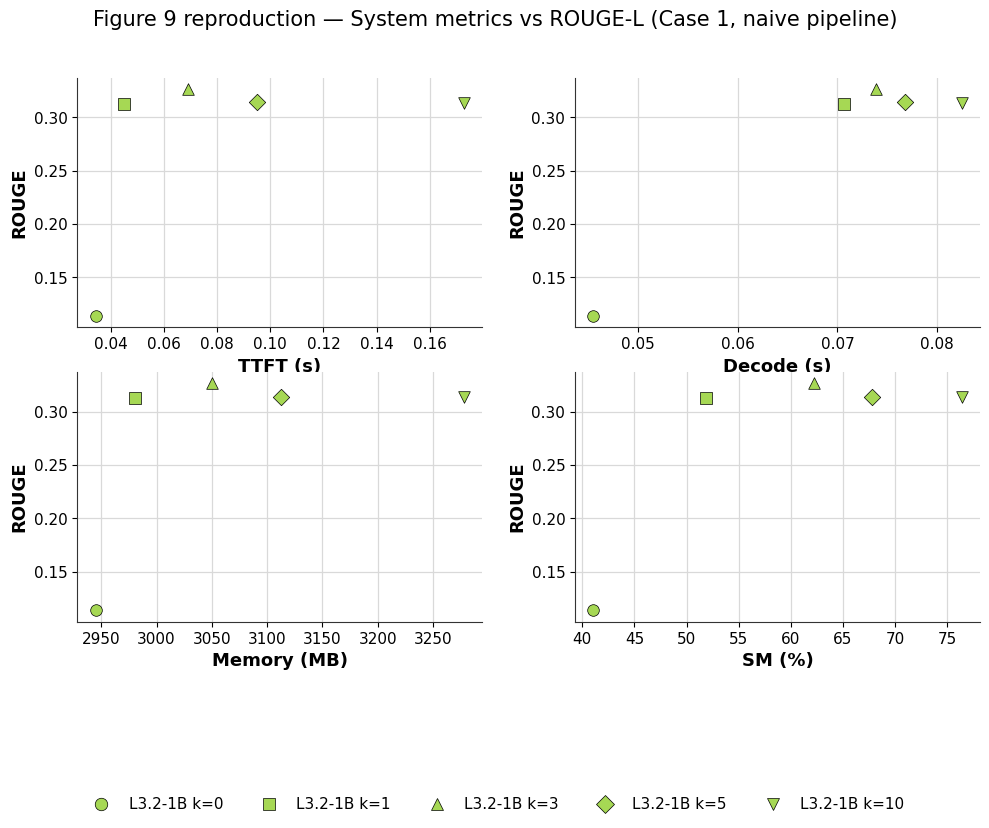

In [11]:
c1_results = df_results[(df_results["rerank"] == 0) & (df_results["compress"] == 0)]
c1_perf    = df_perf[(df_perf["rerank"] == 0) & (df_perf["compress"] == 0)]

GROUP = ["model", "topk"]

if c1_results.empty or c1_perf.empty:
    print("No Case 1 (naive) data found in df_results/df_perf — run a sweep with rerank=False first "
          "(e.g. run_sweep_fig4_fig9.py).")
else:
    rouge_tbl = c1_results.groupby(GROUP)["rouge"].mean().reset_index()

    perf_cols = {
        "ttft": "ttft",
        "decode_time": "decode_time",
        "gen_gpu_all_after_gpu_0_peak": "memory_mb",
        "util_mean_gpu0_sm_pct": "sm_pct",
    }
    present = {k: v for k, v in perf_cols.items() if k in c1_perf.columns}
    missing = [k for k in perf_cols if k not in c1_perf.columns]
    if missing:
        print(f"Skipping unavailable df_perf columns: {missing}")

    perf_tbl = c1_perf.groupby(GROUP)[list(present.keys())].mean().reset_index().rename(columns=present)
    fig9_tbl = rouge_tbl.merge(perf_tbl, on=GROUP, how="inner")

    models = [m for m in MODEL_ORDER if m in fig9_tbl["model"].unique()]
    topks = sorted(fig9_tbl["topk"].unique())

    # Marker shapes matched to the paper: k=0 circle, k=1 square, k=3 triangle-up, k=5 diamond, k=10 triangle-down.
    TOPK_MARKER_DEFAULT = {0: "o", 1: "s", 3: "^", 5: "D", 10: "v"}
    fallback_markers = ["P", "X", "*", "h"]
    topk_marker = {k: TOPK_MARKER_DEFAULT.get(k, fallback_markers[i % len(fallback_markers)])
                   for i, k in enumerate(topks)}

    panels = [("ttft", "TTFT (s)"), ("decode_time", "Decode (s)"),
              ("memory_mb", "Memory (MB)"), ("sm_pct", "SM (%)")]
    panels = [(c, l) for c, l in panels if c in fig9_tbl.columns]

    fig, axes = plt.subplots(2, 2, figsize=(10, 8.5))
    axes = axes.flatten()

    for ax, (col, label) in zip(axes, panels):
        for model in models:
            msub = fig9_tbl[fig9_tbl["model"] == model]
            for topk in topks:
                row = msub[msub["topk"] == topk]
                if row.empty:
                    continue
                ax.scatter(row[col], row["rouge"], color=MODEL_COLOR[model],
                           marker=topk_marker[topk], s=70, edgecolor="black",
                           linewidth=0.5, zorder=3)
        ax.set_xlabel(label, fontsize=FS_LABEL, color=INK, fontweight="bold")
        ax.set_ylabel("ROUGE", fontsize=FS_LABEL, color=INK, fontweight="bold")
        style_axes(ax, grid_axis="both")

    for j in range(len(panels), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    fig.subplots_adjust(bottom=0.26, top=0.90)

    # Single combined legend grid (model x topk), matching the paper's layout.
    legend_handles, legend_labels = [], []
    for model in models:
        for topk in topks:
            legend_handles.append(plt.Line2D([0], [0], marker=topk_marker[topk], linestyle="",
                                              color=MODEL_COLOR[model], markeredgecolor="black",
                                              markeredgewidth=0.5, markersize=9))
            legend_labels.append(f"{MODEL_LABELS.get(model, model)} k={topk}")

    fig.legend(legend_handles, legend_labels, loc="lower center", ncol=len(topks),
               bbox_to_anchor=(0.5, 0.02), frameon=False, fontsize=FS_LEGEND)

    fig.suptitle("Figure 9 reproduction — System metrics vs ROUGE-L (Case 1, naive pipeline)",
                 fontsize=FS_SUPTITLE, color=INK)

    PLOTS_DIR = AE_EVAL_DIR / "figures" / "plots"
    DATA_DIR  = AE_EVAL_DIR / "figures" / "data"
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    fig_path = PLOTS_DIR / "fig9_case1_naive.png"
    data_path = DATA_DIR / "fig9_case1_naive_data.csv"
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    fig9_tbl.to_csv(data_path, index=False)
    print(f"Saved figure to {fig_path}")
    print(f"Saved underlying data ({len(fig9_tbl)} rows, one per model x topk) to {data_path}")

    plt.show()

## Figure 5 reproduction — Compression-rate latency (Case 3)

Per-stage latency (Embed / FAISS / Compress / TTFT / Decode) vs. compression rate `r`, faceted by `topk`, for a single model (defaults to the paper's `Meta-Llama-3-8B-Instruct`, change `MODEL_TO_PLOT` below to switch). Requires a sweep run with compression enabled (`run_sweep_fig5.py`).

**Note on compression latency, same issue as Figure 4's rerank stage:** `df_perf["compress"]` is the on/off config flag (0/1) parsed from the filename, not a duration. `load_evals_executed.ipynb`'s own loading cell (`for k, v in cfg.items(): df[k] = v` in the `df_perf` build step) overwrites whatever `"compress"` column came from the raw CSV with that flag — same collision pattern as `"rerank"`, just introduced here in the notebook rather than in `run_sweep.py`. The actual per-query compression duration is recovered from `df_trace`'s `dur_compress` column instead, computed independently from the `tracer.mark("compress_start"/"compress_end")` calls in `rag_system/pipelines/standard.py`. As with `dur_rerank`, trace data is only sampled for the first 30 queries per config (`do_trace = idx < 30` in `run_sweep.py`), so `dur_compress` is a mean over that subset rather than the full eval set.

Units here are seconds (matching the paper's Figure 5 axis label), unlike the Figure 4 cell above which uses milliseconds — each follows its own paper figure's axis.

Saved figure to /mnt/nvme1n1p1/zman/RAGMark/ae_evaluation/figures/plots/fig5_case3_compression_Llama-3.2-1B-Instruct.png
Saved underlying data (16 rows, one per topk x compression rate) to /mnt/nvme1n1p1/zman/RAGMark/ae_evaluation/figures/data/fig5_case3_compression_Llama-3.2-1B-Instruct_data.csv


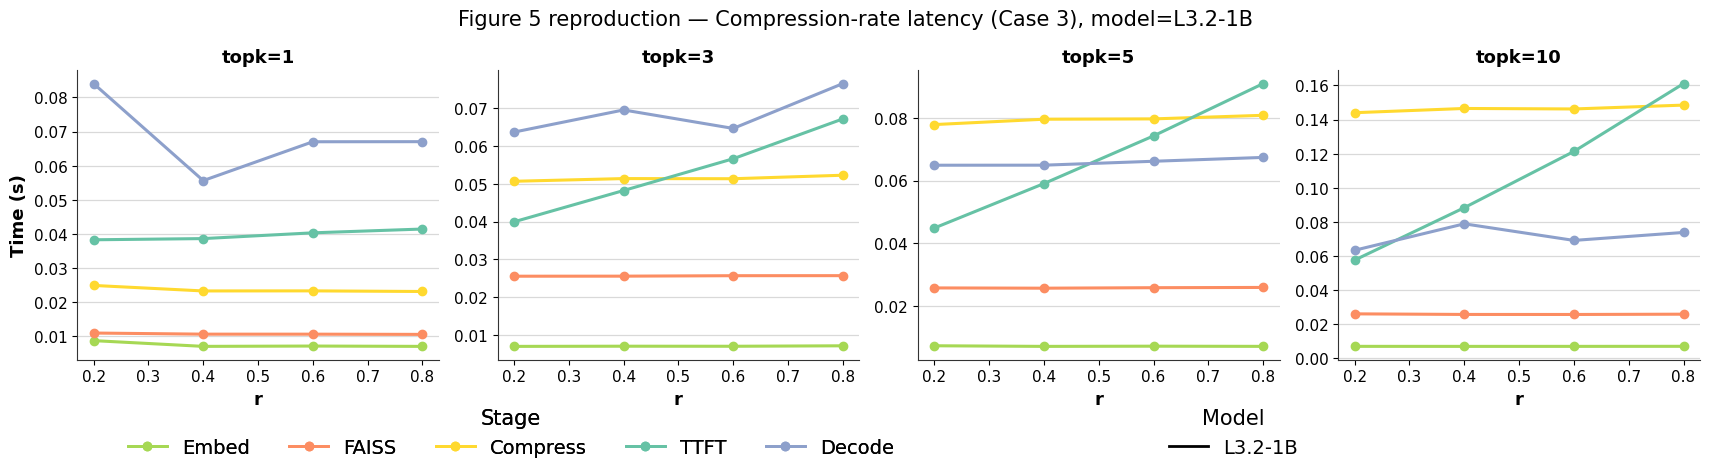

In [12]:
# Uses PALETTE / INK / GRID_COLOR / style_axes / MODEL_ORDER / MODEL_LABELS / STAGE_LABEL / STAGE_COLOR /
# FS_TICK / FS_LABEL / FS_TITLE / FS_LEGEND / FS_LEGEND_TITLE / FS_SUPTITLE defined in the Figure 4 cell above.
MODEL_TO_PLOT = "Llama-3.2-1B-Instruct"  # change to any model present in df_results["model"]

STAGE_COLS_C3 = ["embed", "faiss", "dur_compress", "ttft", "decode_time"]

c3_perf  = df_perf[df_perf["compress"] == 1]
c3_trace = df_trace[df_trace["compress"] == 1] if len(df_trace) else df_trace

if c3_perf.empty:
    print("No Case 3 (compression) data found in df_perf — run a sweep with compression enabled first "
          "(run_sweep_fig5.py).")
elif MODEL_TO_PLOT not in c3_perf["model"].unique():
    print(f"MODEL_TO_PLOT={MODEL_TO_PLOT!r} not found. Models available: {sorted(c3_perf['model'].unique())}")
else:
    GROUP = ["model", "topk", "compress_r"]

    perf_tbl = c3_perf.groupby(GROUP)[["embed", "faiss", "ttft", "decode_time"]].mean().reset_index()

    if len(c3_trace) and "dur_compress" in c3_trace.columns:
        compress_tbl = c3_trace.groupby(GROUP)["dur_compress"].mean().reset_index()
    else:
        compress_tbl = pd.DataFrame(columns=GROUP + ["dur_compress"])

    fig5_tbl = perf_tbl.merge(compress_tbl, on=GROUP, how="left")
    fig5_tbl["dur_compress"] = fig5_tbl["dur_compress"].fillna(0.0)
    fig5_tbl = fig5_tbl[fig5_tbl["model"] == MODEL_TO_PLOT]

    topks = sorted(fig5_tbl["topk"].unique())
    rates = sorted(fig5_tbl["compress_r"].unique())

    fig, axes = plt.subplots(1, len(topks), figsize=(4.3 * len(topks), 4.8), sharex=True)
    axes = np.atleast_1d(axes)

    for ax, topk in zip(axes, topks):
        sub = fig5_tbl[fig5_tbl["topk"] == topk].set_index("compress_r").reindex(rates)
        for stage in STAGE_COLS_C3:
            ax.plot(rates, sub[stage].values, marker="o", markersize=6, linewidth=2.2,
                    color=STAGE_COLOR[stage], label=STAGE_LABEL[stage], zorder=3)
        ax.set_title(f"topk={topk}", fontsize=FS_TITLE, color=INK, fontweight="bold")
        ax.set_xlabel("r", fontsize=FS_LABEL, color=INK, fontweight="bold")
        style_axes(ax)

    axes[0].set_ylabel("Time (s)", fontsize=FS_LABEL, color=INK, fontweight="bold")

    plt.tight_layout()
    fig.subplots_adjust(bottom=0.32)

    # Larger, closer-together legends (overrides the shared FS_LEGEND* sizes for this figure only).
    FS_LEGEND_C3, FS_LEGEND_TITLE_C3 = 14, 15

    stage_handles = [plt.Line2D([0], [0], color=STAGE_COLOR[s], marker="o", linewidth=2) for s in STAGE_COLS_C3]
    leg1 = fig.legend(stage_handles, [STAGE_LABEL[s] for s in STAGE_COLS_C3], title="Stage",
                       loc="lower center", ncol=len(STAGE_COLS_C3), bbox_to_anchor=(0.30, 0.08),
                       frameon=False, fontsize=FS_LEGEND_C3, title_fontsize=FS_LEGEND_TITLE_C3)
    fig.add_artist(leg1)
    model_handle = [plt.Line2D([0], [0], color=INK, linewidth=2)]
    fig.legend(model_handle, [MODEL_LABELS.get(MODEL_TO_PLOT, MODEL_TO_PLOT)], title="Model",
               loc="lower center", ncol=1, bbox_to_anchor=(0.72, 0.08),
               frameon=False, fontsize=FS_LEGEND_C3, title_fontsize=FS_LEGEND_TITLE_C3)

    fig.suptitle(f"Figure 5 reproduction — Compression-rate latency (Case 3), model={MODEL_LABELS.get(MODEL_TO_PLOT, MODEL_TO_PLOT)}",
                 y=1.05, fontsize=FS_SUPTITLE, color=INK)

    PLOTS_DIR = AE_EVAL_DIR / "figures" / "plots"
    DATA_DIR  = AE_EVAL_DIR / "figures" / "data"
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    fig_path = PLOTS_DIR / f"fig5_case3_compression_{MODEL_TO_PLOT}.png"
    data_path = DATA_DIR / f"fig5_case3_compression_{MODEL_TO_PLOT}_data.csv"
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    fig5_tbl.to_csv(data_path, index=False)
    print(f"Saved figure to {fig_path}")
    print(f"Saved underlying data ({len(fig5_tbl)} rows, one per topk x compression rate) to {data_path}")

    plt.show()